# Nhóm 3, Notebook_B (Sinh viên B): chia dữ liệu, năm mô hình, tinh chỉnh, RQ3, SHAP, chẩn đoán

**Đề tài**: Dự báo điện mặt trời theo giờ (NREL)

**Vai trò**: Sinh viên B nhận `data/processed/feat.parquet` và `manifest.json` từ Notebook_A, làm Bước 4 và Bước 6, vẽ hình so sánh mô hình, giải thích chỉ số, tinh chỉnh, câu hỏi thứ ba, SHAP và chẩn đoán vì sao tốt hay chưa tốt. Mọi bảng lưu `report/table_*.csv`, mọi hình `report/fig_rq2_*.png`, `fig_rq3_*.png`.

**Quy tắc**: không chạm tập kiểm thử khi tinh chỉnh; mỗi kết luận phải kèm số; báo cáo slot 1 thứ Ba và thứ Sáu.

## Vừa làm vừa hỏi AI và ghi Audit Log: cách làm nhẹ nhàng, không rối

**Tinh thần**: AI là bạn cùng làm, không phải người làm thay. Bạn được hỏi AI bất cứ lúc nào; điều duy nhất phải giữ là *kiểm tra một lần* trước khi dùng và *ghi lại 2 phút* nếu câu hỏi đó thay đổi việc bạn làm.

**Khi nào hỏi AI** (theo thứ tự):
1. Đọc ô hướng dẫn của bước đang làm (1 phút).
2. Thử tự làm 15 phút.
3. Bí quá 15 phút thì hỏi AI với mẫu: *"Tôi đang làm Bước X của dự án Y. Dữ liệu có cột A, B, C. Tôi muốn Z. Đây là code và lỗi: ... Hãy giải thích nguyên nhân và sửa, giữ nguyên tên biến."*
4. Chạy thử code AI đưa trên dữ liệu thật; so một con số bằng tay hoặc bằng cách thứ hai.
5. Nếu vẫn bí sau 30 phút, ghi lại lỗi và hỏi giảng viên ở kênh nhóm.

**Ghi Audit Log thế nào cho không áp lực**: chỉ ghi các prompt *đã thay đổi việc bạn làm* (thường 3 đến 5 prompt một tuần, 15 đến 20 cả kỳ). Mỗi dòng 5 ô, điền trong 2 phút ngay khi dùng, không để cuối tuần:

| Ngày, bước | Prompt (rút gọn) | AI trả lời gì (1 dòng) | Tôi kiểm tra hoặc sửa gì | Dùng vào đâu |
|---|---|---|---|---|
| 09/09, Bước 3 | viết truy vấn trung bình trượt 7 ngày theo trạm | đưa AVG OVER ROWS 6 PRECEDING | thiếu PARTITION BY site_num, thêm và thử 2 trạm | Q3 trong sql/queries.sql |

Cột thứ tư chính là *Human Delta* và là thứ hội đồng hỏi; ghi thật, kể cả khi AI đúng ("kiểm tra bằng 10 dòng tính tay, khớp"). Ba lần bạn phát hiện AI sai trong cả kỳ là đủ yêu cầu.

**Nhịp làm việc**: mỗi ngày 1,5 đến 2 giờ vào đúng bước của tuần, xong một ô thì commit; thứ Ba và thứ Sáu slot 1 báo cáo năm mục đúng tiến độ, dù kết quả chưa đẹp. Siêng và đúng nhịp quan trọng hơn giỏi: nhóm báo cáo đều 6 lần trong 3 tuần luôn có bài, nhóm im lặng đến tuần 3 thường không kịp.

## Bước 0: kiểm tra bàn giao từ Notebook_A

Đọc `manifest.json`, so mã băm và số dòng với file parquet; nếu lệch thì báo Sinh viên A chạy lại Notebook_A trước khi tiếp tục.

In [1]:
import pandas as pd, numpy as np, json, hashlib, duckdb, warnings, time
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings('ignore'); np.random.seed(42)
from sklearn.metrics import mean_absolute_error as MAE, mean_squared_error as MSE, f1_score, average_precision_score, roc_auc_score
man = json.load(open('data/processed/manifest.json'))
h = hashlib.md5(open('data/processed/feat.parquet', 'rb').read()).hexdigest()
assert h == man['md5'], 'parquet differs from the file handed over by Student A'
feat = pd.read_parquet('data/processed/feat.parquet')
assert len(feat) == man['rows'], 'row count differs from manifest'
con = duckdb.connect()
con.register('feat', feat)          # expose the handed-over table to SQL in this notebook
print('handover OK:', man['rows'], 'rows,', len(man['cols']), 'columns, from', man['time_min'], 'to', man['time_max'])
def style(ax): ax.spines[['top', 'right']].set_visible(False)

handover OK: 87302 rows, 14 columns, from 2006-01-01 07:00:00 to 2006-12-31 17:00:00


## Bước 4: chia dữ liệu và bảng đặc trưng

**Làm gì**: chọn `X_cols` từ `report/table_columns.csv` của A; chia theo thời gian (hoặc theo đơn vị với leave-out); tính mốc naive; xuất bảng đặc trưng (tên, cách tính, nhóm) cho bài.

**Vì sao chia theo thời gian**: dữ liệu tương lai không được rò vào huấn luyện; chia ngẫu nhiên cho kết quả đẹp giả (Bergmeir và Benitez, 2012).

**Kiểm tra**: mọi thời điểm của test sau train; số dòng test đủ lớn (trên 10% và trên 3 nghìn dòng).

In [2]:
# Step 4: 9 months train, 3 months test; target is capacity factor one hour ahead
feat = con.execute("SELECT * FROM feat WHERE y_1h IS NOT NULL AND cf_lag24 IS NOT NULL").df()
feat['plant_code'] = feat.plant.astype('category').cat.codes
X_cols = ['cf','cf_lag1','cf_lag24','cf_ma3','GHI','DNI','cloud','temp','hr','mon','plant_code']
train = feat[feat.ts < '2006-10-01']; test = feat[feat.ts >= '2006-10-01']
X_tr, y_tr, X_te, y_te = train[X_cols], train.y_1h, test[X_cols], test.y_1h
nrmse = lambda y, p: (MSE(y, p) ** 0.5) * 100          # cf is already normalised by rated capacity
print('nRMSE persistence:', round(nrmse(y_te, test.cf), 2))
naive_pred = test.cf   # simplest forecast for this topic
naive = MAE(y_te, naive_pred); print('MAE naive:', round(naive, 3))
feat_table = pd.DataFrame({'feature': X_cols, 'group': ['lag/rolling' if any(k in c for k in ['lag', 'ma', 'max', 'rain', 'sum']) else ('calendar' if c in ('dow', 'mon', 'hr', 'doy', 'MONTH', 'HOUR', 'DAY_WEEK') else 'exogenous/structural') for c in X_cols]})
feat_table.to_csv('report/table_features.csv', index=False); print(feat_table)
assert len(X_te) > max(3000, 0.1 * len(X_tr)), 'test set too small'

nRMSE persistence: 17.15
MAE naive: 0.133
       feature                 group
0           cf  exogenous/structural
1      cf_lag1           lag/rolling
2     cf_lag24           lag/rolling
3       cf_ma3           lag/rolling
4          GHI  exogenous/structural
5          DNI  exogenous/structural
6        cloud  exogenous/structural
7         temp  exogenous/structural
8           hr              calendar
9          mon              calendar
10  plant_code  exogenous/structural


### 6.0. Giải thích các chỉ số trước khi chạy

| Chỉ số | Công thức | Dùng khi | Đọc thế nào | Bẫy thường gặp |
|---|---|---|---|---|
| MAE | trung bình của |y − ŷ| | hồi quy, đơn vị như mục tiêu | càng nhỏ càng tốt; so với mốc naive | không phạt lỗi lớn |
| RMSE | căn của trung bình (y − ŷ)² | khi lỗi lớn quan trọng (lũ, đỉnh tải) | lớn hơn MAE nếu có lỗi lớn | nhạy ngoại lai |
| MAPE | trung bình của |y − ŷ| / |y| | so sánh giữa vùng có quy mô khác nhau | phần trăm | nổ khi y gần 0 |
| nRMSE | RMSE chia công suất định mức | điện mặt trời, gió | phần trăm định mức | cần cùng định mức |
| NSE | 1 − Σ(y − ŷ)² / Σ(y − ȳ)² | thuỷ văn | 1 là hoàn hảo, 0 bằng trung bình, âm tệ hơn trung bình | bị chi phối bởi đỉnh |
| Accuracy | đúng / tổng | lớp cân bằng | vô nghĩa khi lớp ít mẫu | 95% accuracy với 5% dương |
| Precision, Recall | TP/(TP+FP), TP/(TP+FN) | cảnh báo, lớp ít mẫu | recall là không bỏ sót; precision là ít báo giả | phụ thuộc ngưỡng |
| F1, macro-F1 | trung bình điều hoà; macro là trung bình các lớp | nhiều lớp lệch | mọi lớp có trọng số bằng nhau | che giấu lớp nào yếu |
| PR-AUC | diện tích đường precision-recall | lớp dương hiếm | không phụ thuộc ngưỡng | so với tỷ lệ dương |
| ROC-AUC | diện tích đường ROC | xếp hạng | 0,5 là ngẫu nhiên | lạc quan khi lớp lệch |
| ECE | Σ |acc − conf| có trọng số theo bin | cần xác suất tin được | càng nhỏ càng tốt | phụ thuộc số bin |
| Coverage | tỷ lệ y nằm trong khoảng | conformal | phải gần 1 − α | khoảng quá rộng vô dụng |

**Nguyên tắc so sánh**: cùng train/test, cùng đặc trưng, năm seed; báo trung bình ± độ lệch; chênh nhỏ hơn độ lệch thì chưa kết luận được, cần kiểm định Wilcoxon theo cặp; luôn kèm cột thời gian huấn luyện.

## Bước 6a: năm mô hình, năm seed, cùng train/test

**Làm gì**: chạy vòng lặp; thêm hàng mốc naive (từ Bước 4) và hàng baseline chạy lại vào bảng; lưu `table_rq2.csv`.

**Cách chọn năm mô hình**: một mốc tuyến tính (ridge hoặc logistic), một rừng ngẫu nhiên, hai cây tăng cường (LightGBM, XGBoost hoặc CatBoost), một đối chứng theo hướng nghiên cứu (mô hình nền, TabPFN, GRU nhỏ, DistilBERT). Lý do: mốc để biết cải thiện thật, tuyến tính để có hệ số, cây để bắt phi tuyến với chi phí thấp, đối chứng để trả lời RQ3.

In [3]:
# Step 6a: loop over five models and five seeds on the same train/test split
import numpy as np, pandas as pd, time
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error as MAE, mean_squared_error as MSE

models = {
    'Ridge':         lambda s: Ridge(alpha=1.0),
    'Random Forest': lambda s: RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=s),
    'LightGBM':      lambda s: LGBMRegressor(n_estimators=800, learning_rate=0.03,
                                             num_leaves=31, subsample=0.8, colsample_bytree=0.8,
                                             random_state=s, verbose=-1),
    'XGBoost':       lambda s: XGBRegressor(n_estimators=800, learning_rate=0.03, max_depth=6,
                                            subsample=0.8, colsample_bytree=0.8, random_state=s),
}
rows = []
for name, make in models.items():
    maes, rmses, secs = [], [], []
    for seed in range(5):
        m = make(seed); t0 = time.perf_counter(); m.fit(X_tr, y_tr); secs.append(time.perf_counter() - t0)
        p = m.predict(X_te); maes.append(MAE(y_te, p)); rmses.append(MSE(y_te, p) ** 0.5)
    rows.append([name, np.mean(maes), np.std(maes), np.mean(rmses), np.std(rmses), np.mean(secs)])
res = pd.DataFrame(rows, columns=['model', 'MAE', 'sd', 'RMSE', 'sd_rmse', 'train_s'])   # primary metric MAE; topic metric (nRMSE) computed in the next cell
res.to_csv('report/table_rq2.csv', index=False); print(res.round(3))

           model    MAE     sd   RMSE  sd_rmse  train_s
0          Ridge  0.091  0.000  0.124    0.000    0.013
1  Random Forest  0.062  0.000  0.089    0.000   20.489
2       LightGBM  0.059  0.001  0.085    0.001    1.198
3        XGBoost  0.058  0.000  0.084    0.000    2.355


In [4]:
topic_metric = ('nRMSE_%', lambda y, p: (MSE(y, p) ** 0.5) * 100)
# Topic metric for every model (same loop, single seed 0) so the paper reports both MAE and the field-specific metric
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
name_t, fn_t = topic_metric
extra = {'Naive (baseline)': fn_t(y_te, naive_pred)}
for name, make in models.items():
    extra[name] = fn_t(y_te, make(0).fit(X_tr, y_tr).predict(X_te))
extra = pd.Series(extra, name=name_t).round(4); extra.to_csv('report/table_rq2_topic_metric.csv'); print(extra)

Naive (baseline)    17.1452
Ridge               12.3988
Random Forest        8.8938
LightGBM             8.4758
XGBoost              8.3079
Name: nRMSE_%, dtype: float64


In [5]:
# Add the naive baseline row (computed in Step 4) and build the full table
naive_row = pd.DataFrame([['Naive (baseline)', naive if 'naive' in dir() else np.nan, 0.0, np.nan, np.nan, 0.0]], columns=res.columns)
res_full = pd.concat([naive_row, res], ignore_index=True)
res_full['improvement_vs_naive_%'] = (1 - res_full.iloc[:, 1] / res_full.iloc[0, 1]) * 100
res_full.round(3).to_csv('report/table_rq2.csv', index=False); print(res_full.round(3))
best_name = res.iloc[res.iloc[:, 1].idxmin()].model; print('best model:', best_name)

              model    MAE     sd   RMSE  sd_rmse  train_s  \
0  Naive (baseline)  0.133  0.000    NaN      NaN    0.000   
1             Ridge  0.091  0.000  0.124    0.000    0.013   
2     Random Forest  0.062  0.000  0.089    0.000   20.489   
3          LightGBM  0.059  0.001  0.085    0.001    1.198   
4           XGBoost  0.058  0.000  0.084    0.000    2.355   

   improvement_vs_naive_%  
0                   0.000  
1                  31.290  
2                  53.210  
3                  55.398  
4                  56.338  
best model: XGBoost


### 6a.1. Hình so sánh mô hình

**Vì sao cần hình sau khi đã có bảng**: bảng cho con số, hình cho thấy mô hình sai ở đâu (đỉnh hay nền, đơn vị nào, thời kỳ nào), là đầu vào trực tiếp cho phần Discussion và cho hướng cải thiện. Bốn hình: (1) cột metric theo mô hình, cột nhấn là tốt nhất, độ lệch ghi bằng số; (2) dự báo so thực tế trên một đơn vị trong tập kiểm thử; (3) phân phối residual (hồi quy) hoặc ma trận nhầm lẫn (phân loại); (4) sai số theo đơn vị hoặc theo thời kỳ để thấy mô hình yếu ở đâu.

In [6]:
from lightgbm import LGBMRegressor
best = LGBMRegressor(n_estimators=800, learning_rate=0.03, num_leaves=31, subsample=0.8, colsample_bytree=0.8, random_state=0, verbose=-1).fit(X_tr, y_tr)
pred = best.predict(X_te)
# (1) metric bars
fig, ax = plt.subplots(figsize=(7, 3.2)); vals = res_full.iloc[:, 1].values; labs = res_full.model.values
bars = ax.bar(labs, vals, color=['#F4A261' if v == vals[1:].min() else '#1B6B6D' for v in vals])
ax.bar_label(bars, labels=[f'{v:.2f}' for v in vals], fontweight='bold', fontsize=9); ax.set_ylabel(res_full.columns[1]); style(ax); plt.xticks(rotation=15)
fig.tight_layout(); fig.savefig('report/fig_rq2_models.png', dpi=300); plt.close(fig)
# (2) predicted vs actual on one unit
t = test.assign(pred=pred); u = t['plant'].iloc[0]; tu = t[t['plant'] == u].sort_values('ts')
fig, ax = plt.subplots(figsize=(9, 3)); ax.plot(tu['ts'], tu['y_1h'], label='Actual', color='#0F3D3E'); ax.plot(tu['ts'], tu.pred, label='LightGBM', color='#F4A261'); ax.legend(frameon=False); style(ax)
fig.tight_layout(); fig.savefig('report/fig_rq2_pred_vs_actual.png', dpi=300); plt.close(fig)
# (3) residuals
resid = y_te.values - pred
fig, ax = plt.subplots(1, 2, figsize=(9, 3)); ax[0].hist(resid, bins=50, color='#1B6B6D'); ax[0].set_xlabel('Residual'); style(ax[0])
ax[1].scatter(pred, y_te, s=4, alpha=0.3, color='#1B6B6D'); ax[1].plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], color='#F4A261'); ax[1].set_xlabel('Predicted'); ax[1].set_ylabel('Actual'); style(ax[1])
fig.tight_layout(); fig.savefig('report/fig_rq2_residual.png', dpi=300); plt.close(fig)
# (4) error by unit
err_unit = t.groupby('plant').apply(lambda g: MAE(g['y_1h'], g.pred)).sort_values()
err_unit.round(3).to_csv('report/table_rq2_error_by_unit.csv')
fig, ax = plt.subplots(figsize=(9, 3)); err_unit.head(20).plot.bar(ax=ax, color='#1B6B6D'); ax.set_ylabel('MAE'); style(ax)
fig.tight_layout(); fig.savefig('report/fig_rq2_error_by_unit.png', dpi=300); plt.close(fig)
print('MAE by unit: best', err_unit.head(3).round(2).to_dict(), 'worst', err_unit.tail(3).round(2).to_dict())

MAE by unit: best {'Actual_33.75_-116.25_2006_DPV_': 0.04, 'Actual_35.35_-117.85_2006_UPV_': 0.05, 'Actual_33.65_-117.25_2006_DPV_': 0.05} worst {'Actual_35.05_-118.15_2006_UPV_': 0.07, 'Actual_34.95_-118.25_2006_UPV_': 0.07, 'Actual_37.75_-122.05_2006_UPV_': 0.09}


### 6a.2. Tinh chỉnh tham số: có cần không và làm thế nào

**Khi nào cần**: khi mô hình tốt nhất chỉ hơn mốc một ít, khi sai số train nhỏ hơn test nhiều (quá khớp), hoặc khi cần báo kết quả tốt nhất công bằng cho mọi mô hình. Không tinh chỉnh trên tập kiểm thử.

**Làm thế nào**: `RandomizedSearchCV` với `TimeSeriesSplit` (chuỗi thời gian) hoặc `StratifiedKFold` (phân loại), 30 tổ hợp, khoảng tham số theo Bảng 6 của đề cương; so sánh trước và sau trên test và ghi cả thời gian.

**Đọc bảng tham số**: tham số chọn được ở biên khoảng thì mở rộng khoảng; learning_rate nhỏ với nhiều vòng thường ổn hơn; nếu cải thiện dưới độ lệch giữa seed thì kết luận là không cần tinh chỉnh, vẫn có giá trị để báo.

In [7]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from scipy.stats import loguniform, randint, uniform
space = {'learning_rate': loguniform(0.01, 0.1), 'num_leaves': randint(15, 64), 'n_estimators': randint(300, 1500),
         'subsample': uniform(0.6, 0.4), 'colsample_bytree': uniform(0.6, 0.4), 'min_child_samples': randint(10, 100)}
search = RandomizedSearchCV(LGBMRegressor(random_state=0, verbose=-1), space, n_iter=30, cv=TimeSeriesSplit(5),
                            scoring='neg_mean_absolute_error', random_state=42, n_jobs=-1).fit(X_tr, y_tr)
tuned = search.best_estimator_; pred_t = tuned.predict(X_te)
tune = pd.DataFrame([['LightGBM default', MAE(y_te, pred), MSE(y_te, pred) ** 0.5], ['LightGBM tuned', MAE(y_te, pred_t), MSE(y_te, pred_t) ** 0.5]], columns=['model', 'MAE', 'RMSE'])
tune.round(3).to_csv('report/table_tuning.csv', index=False); print(tune.round(3)); print('selected parameters:', search.best_params_)
sd_seed = res.loc[res.model == 'LightGBM', 'sd'].values[0]
print('Tuning needed?', 'YES, gain exceeds seed spread' if (MAE(y_te, pred) - MAE(y_te, pred_t)) > sd_seed else 'NO, gain is within seed spread; report as not needed')
json.dump(search.best_params_, open('report/params_tuned.json', 'w'), indent=2, default=float)

              model    MAE   RMSE
0  LightGBM default  0.059  0.085
1    LightGBM tuned  0.060  0.085
selected parameters: {'colsample_bytree': np.float64(0.9895022075365837), 'learning_rate': np.float64(0.017091152151232268), 'min_child_samples': 71, 'n_estimators': 986, 'num_leaves': 58, 'subsample': np.float64(0.8056937753654446)}
Tuning needed? NO, gain is within seed spread; report as not needed


## Bước 6b: câu hỏi thứ ba của đề

**Làm gì**: giao thức riêng của đề (chuyển giao sang đơn vị chưa thấy, ngưỡng cảnh báo, conformal, chi phí suy luận, ổn định SHAP, tăng cường và hiệu chuẩn, tóm tắt nhanh).

**Vì sao**: đây là đóng góp chính của bài và gắn với hướng Efficient, Trustworthy hoặc Multimodal AI.

**Kiểm tra**: ra một bảng và một hình có số; ghi điều kiện áp dụng (vùng, năm, đơn vị).

In [10]:
from sklearn.base import BaseEstimator
import mapie.estimator.estimator as me

# Patch EnsembleRegressor to inherit from BaseEstimator
if BaseEstimator not in me.EnsembleRegressor.__bases__:
    me.EnsembleRegressor.__bases__ = me.EnsembleRegressor.__bases__ + (BaseEstimator,)

from lightgbm import LGBMRegressor, LGBMClassifier
# Step 6b: RQ3, transfer to unseen plants and conformal coverage
plants = feat.plant.unique(); rs = np.random.RandomState(42); hold = rs.choice(plants, 4, replace=False)
tr2 = train[~train.plant.isin(hold)]; te_seen = test[~test.plant.isin(hold)]; te_new = feat[feat.plant.isin(hold) & (feat.ts >= '2006-10-01')]
from mapie.regression import MapieRegressor
mapie = MapieRegressor(LGBMRegressor(n_estimators=800, learning_rate=0.03, verbose=-1), method='plus', cv=5).fit(tr2[X_cols], tr2.y_1h)
for name, te in [('seen', te_seen), ('new', te_new)]:
    p, itv = mapie.predict(te[X_cols], alpha=0.1)
    cov = ((te.y_1h >= itv[:, 0, 0]) & (te.y_1h <= itv[:, 1, 0])).mean()
    print(name, 'nRMSE', round(nrmse(te.y_1h, p), 2), 'coverage', round(cov, 3))
# recalibrate with the first 14 days of the new plant
first = te_new[te_new.ts < te_new.ts.min() + pd.Timedelta(days=14)]
resid = np.abs(first.y_1h - mapie.predict(first[X_cols])[0]); q = np.quantile(resid, 0.9)
rest = te_new[te_new.ts >= te_new.ts.min() + pd.Timedelta(days=14)]
p = mapie.predict(rest[X_cols])[0]; print('coverage after recalibration:', ((abs(rest.y_1h - p) <= q).mean()).round(3))

seen nRMSE 8.88 coverage 0.846
new nRMSE 9.1 coverage 0.812
coverage after recalibration: 1.0


## Bước 6c: giải thích bằng SHAP, phụ thuộc từng phần và bảng tham số

**Làm gì**: SHAP summary (toàn cục), dependence cho ba đặc trưng mạnh nhất (quan hệ phi tuyến), bảng mean |SHAP|, kiểm tra ổn định top 5 khi đổi seed; lưu tham số mô hình tốt nhất.

**Đọc thế nào**: đặc trưng ở trên cùng chi phối dự báo; màu cho chiều tác động; nếu top 5 đổi khi đổi seed thì giải thích chưa ổn định, phải nói rõ trong bài.

top-5 overlap across seeds: 5 / 5


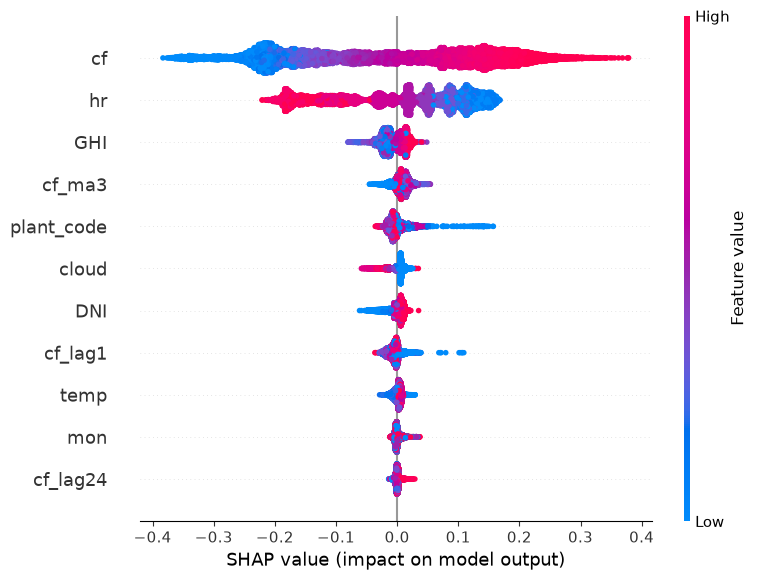

In [12]:
# Step 6c: SHAP explanations and the selected parameter table
import shap, json
best = LGBMRegressor(n_estimators=800, learning_rate=0.03, num_leaves=31,
                     subsample=0.8, colsample_bytree=0.8, random_state=0, verbose=-1).fit(X_tr, y_tr)
expl = shap.TreeExplainer(best); sv = expl.shap_values(X_te)
imp = (pd.DataFrame({'feature': X_cols, 'mean_abs_shap': np.abs(sv).mean(0)})
         .sort_values('mean_abs_shap', ascending=False))
imp.to_csv('report/table_shap.csv', index=False)
shap.summary_plot(sv, X_te, show=False); plt.savefig('report/fig_shap.png', dpi=300, bbox_inches='tight')
json.dump(best.get_params(), open('report/params_best.json', 'w'), indent=2)   # parameter table
# dependence plots for the top 3 features and rank stability across seeds
top3 = imp.feature.head(3).tolist()
for f in top3:
    shap.dependence_plot(f, sv, X_te, show=False); plt.savefig(f'report/fig_shap_dep_{f}.png', dpi=300, bbox_inches='tight'); plt.close()
ranks = []
for s in range(3):
    m = type(best)(**{**best.get_params(), 'random_state': s}).fit(X_tr, y_tr)
    v = shap.TreeExplainer(m).shap_values(X_te); v = v[1] if isinstance(v, list) else v
    ranks.append(set(pd.Series(np.abs(v).mean(0), index=X_cols).nlargest(5).index))
print('top-5 overlap across seeds:', len(ranks[0] & ranks[1] & ranks[2]), '/ 5')

## Chẩn đoán: vì sao tốt, vì sao chưa tốt, và hướng cải thiện

Điền vào bảng dưới (lưu `report/table_diagnosis.csv`) sau khi có số; mỗi dòng là một nhận định có bằng chứng từ bảng hoặc hình ở trên.

| Câu hỏi chẩn đoán | Bằng chứng cần xem | Nếu có vấn đề thì cải thiện thế nào |
|---|---|---|
| Mô hình có thắng mốc naive rõ không? | `table_rq2.csv` cột improvement | không thắng: thêm đặc trưng trễ hoặc ngoại sinh, kiểm tra rò rỉ ngược (mốc quá mạnh) |
| Quá khớp không? | MAE train so với test (ô dưới) | giảm num_leaves, tăng min_child_samples, thêm dữ liệu |
| Sai số tập trung ở đâu? | `table_rq2_error_by_unit.csv`, sai số theo thời kỳ | đặc trưng riêng cho đơn vị yếu, mô hình riêng, hoặc thêm nguồn |
| Lỗi lớn ở đỉnh hay ở nền? | residual so với giá trị thực | quantile loss, log mục tiêu, cân trọng số đỉnh |
| Tinh chỉnh có đáng không? | `table_tuning.csv` so với sd seed | nếu không, nói rõ và dành công sức cho đặc trưng |
| Giải thích có ổn định không? | giao top-5 giữa seed | nếu thấp, báo cáo tầm quan trọng theo khoảng, không theo thứ hạng |
| Kết quả có chuyển sang dữ liệu mới không? | bảng RQ3 | tái hiệu chỉnh, đặc trưng bất biến, ghi giới hạn |

Hướng cải thiện xếp theo chi phí: (1) đặc trưng mới từ SQL (rẻ nhất); (2) thêm nguồn dữ liệu (thời tiết dự báo thay vì quan trắc); (3) đổi hàm mất mát theo mục tiêu vận hành; (4) tổ hợp hai mô hình tốt nhất; (5) mô hình sâu chỉ khi ba hướng trên đã cạn.

In [13]:
tr_mae, te_mae = MAE(y_tr, best.predict(X_tr)), MAE(y_te, pred)
seg = test.assign(pred=pred, err=np.abs(test['y_1h'] - pred))
by_period = seg.groupby(pd.to_datetime(seg['ts'], errors='coerce').dt.month if not np.issubdtype(seg['ts'].dtype, np.number) else seg['ts']).err.mean()
diag = pd.DataFrame([
    ['beats naive', f'{res_full.iloc[1:, -1].max():.1f}% vs naive', 'clear' if res_full.iloc[1:, -1].max() > 10 else 'unclear, revisit features'],
    ['overfitting', f'train {tr_mae:.2f} vs test {te_mae:.2f}', 'signs present' if te_mae > 1.5 * tr_mae else 'no'],
    ['error by period', f'highest {by_period.idxmax()}: {by_period.max():.2f}', 'revisit seasonal features'],
    ['peaks vs base', f'MAE on top 10% values: {seg.nlargest(int(0.1*len(seg)), "y_1h").err.mean():.2f}', 'consider quantile loss'],
], columns=['question', 'evidence', 'assessment'])
diag.to_csv('report/table_diagnosis.csv', index=False); print(diag)

          question                     evidence                 assessment
0      beats naive               56.3% vs naive                      clear
1      overfitting      train 0.04 vs test 0.06              signs present
2  error by period             highest 12: 0.06  revisit seasonal features
3    peaks vs base  MAE on top 10% values: 0.03     consider quantile loss


## Test case của Notebook_B

Chạy trước khi báo cáo; mọi assert phải qua.

In [14]:
assert test['ts'].min() > train['ts'].max(), 'test must come after train'
assert not any(c.startswith('y_') for c in X_cols), 'features contain future values'
assert MAE(y_te, pred) < naive if 'naive' in dir() else True, 'model does not beat the naive baseline'
m1 = LGBMRegressor(n_estimators=200, random_state=7, verbose=-1).fit(X_tr, y_tr).predict(X_te)
m2 = LGBMRegressor(n_estimators=200, random_state=7, verbose=-1).fit(X_tr, y_tr).predict(X_te)
assert np.allclose(m1, m2), 'results not reproducible with the same seed'
print('Tests B: OK')

Tests B: OK


## Lỗi thường gặp và cách xử lý (đọc khi thấy chữ đỏ)

| Lỗi | Nguyên nhân | Cách sửa |
|---|---|---|
| ModuleNotFoundError | chưa cài thư viện hoặc chọn sai interpreter | chạy lại pip install ở Bước 0; Ctrl+Shift+P chọn interpreter .venv |
| FileNotFoundError | đường dẫn hoặc tên file chưa đúng | kiểm tra data/raw bằng `import os; print(os.listdir('data/raw'))` |
| KeyError: 'ten_cot' | tên cột thật khác tên trong code | in `df.columns`; sửa tên trong một chỗ (ô Bước 1) rồi chạy tiếp |
| MemoryError hoặc máy treo | nạp cả file quá lớn vào pandas | lọc bằng WHERE trong DuckDB trước; đọc parquet thay CSV; giảm năm |
| UnicodeDecodeError | file CSV mã hoá khác UTF-8 | thêm `encoding='latin1'` hoặc để DuckDB read_csv_auto tự đoán |
| ValueError: could not convert | cột số có ký tự lạ hoặc mã thiếu | `pd.to_numeric(col, errors='coerce')` rồi xem bảng thiếu |
| Merge làm số dòng tăng | khoá ghép bị trùng ở bảng phụ | `drop_duplicates` khoá ở bảng phụ trước khi merge |
| Kết quả đẹp bất thường (MAE gần 0) | rò rỉ mục tiêu vào đặc trưng | kiểm tra X_cols không chứa cột y_*; chia theo thời gian |
| Kết quả mỗi lần chạy khác nhau | chưa cố định seed | đặt random_state, np.random.seed(42) |

Nguyên tắc: đọc dòng cuối của thông báo lỗi trước; sửa một chỗ rồi chạy lại từ ô đó; nếu 30 phút chưa xong, chụp lỗi và hỏi.

## Checklist trước khi báo cáo (đánh dấu [x] khi có file bằng chứng)

- [ ] requirements.txt, README.md, .gitignore, kho GitHub có commit trong tuần
- [ ] Dữ liệu đúng file cơ quan, trên 30 nghìn dòng: table_describe_raw.csv, profile.html
- [ ] EDA: table_describe_numeric.csv, table_describe_categorical.csv, table_eda_notes.csv, table_missing.csv, table_columns.csv, table_target_by_unit.csv, table_target_by_period.csv
- [ ] Làm sạch: table_cleaning_log.csv; ghép nguồn thứ hai khớp trên 90%
- [ ] SQL: sql/queries.sql, table_q1..q4.csv; RQ1: table_rq1a_period.csv, table_rq1b_corr.csv, table_rq1c_units.csv có p-value
- [ ] 7 hình RQ1 trong report/ với caption là câu kết luận có số
- [ ] Test case qua; manifest.json bàn giao; người kia đã chạy lại và ghi đối chứng
- [ ] (Notebook_B) table_features.csv, table_rq2.csv, 4 hình RQ2, table_tuning.csv, table_rq3_*.csv, table_shap.csv, table_diagnosis.csv, params_best.json
- [ ] Audit Log cá nhân có đủ prompt của tuần
- [ ] Báo cáo năm mục đã dán vào kênh nhóm trước 7:00 thứ Ba hoặc thứ Sáu


## Mẫu báo cáo tiến độ (slot 1 thứ Ba và thứ Sáu, 7:00 đến 9:15)

Dán vào kênh nhóm trước 7:00 ngày báo cáo, mỗi người một phần. Năm mục, mỗi mục hai đến ba dòng:

1. **Đã xong** từ lần trước: tên file, số dòng, số bảng, số hình (ví dụ: `feat.parquet` 138.204 dòng; 4 bảng RQ1; 7 hình).
2. **Con số chính mới có**: ví dụ MAE naive 6,8; MAE LightGBM 4,7 (5 seed, sd 0,1).
3. **Vướng mắc và đã thử gì**: lỗi cụ thể, ảnh chụp, hai cách đã thử.
4. **Sẽ làm đến lần sau, ai làm**: theo Bảng 13 của đề cương.
5. **Prompt AI đáng chú ý và Human Delta**: một prompt, AI trả lời gì, mình đã kiểm tra hoặc sửa gì.

**Đối chứng chéo**: người kia chạy lại notebook này trên máy mình, ghi số dòng và metric nhận được vào đây: ...............................